In [2]:
import pandas as pd

# 读取数据
df = pd.read_csv('./Updated Data/co2.csv')

print('数据基本信息：')
df.info()
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('Unnamed: 0.1', axis=1)

df.to_csv('./Updated Data/co2.csv')
df.info()

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8397 entries, 0 to 8396
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      8397 non-null   int64  
 1   Total CO₂ emissions [m tonnes]  8397 non-null   float64
 2   Time spent at sea [hours]       8397 non-null   float64
 3   length                          8397 non-null   float64
 4   breadth                         8397 non-null   float64
 5   draught                         8397 non-null   float64
 6   gross_tonnage                   8397 non-null   float64
 7   deadweight                      8397 non-null   float64
 8   max_speed                       8397 non-null   float64
 9   avg_speed                       8397 non-null   float64
 10  engine_power                    8397 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 721.7 KB


KeyError: "['Unnamed: 0.1'] not found in axis"

Feature Means:
 Time spent at sea [hours]          2212.702123
avg_speed                            11.764856
length                              201.592950
breadth                              31.128498
gross_tonnage                     40211.514708
deadweight                        53549.148863
engine_power                      15106.928375
Total CO₂ emissions [m tonnes]    10869.116377
dtype: float64

Feature Variances:
 Time spent at sea [hours]         2.491955e+06
avg_speed                         9.992006e+00
length                            3.624155e+03
breadth                           8.416131e+01
gross_tonnage                     1.261209e+09
deadweight                        2.416585e+09
engine_power                      2.156794e+08
Total CO₂ emissions [m tonnes]    1.801670e+08
dtype: float64


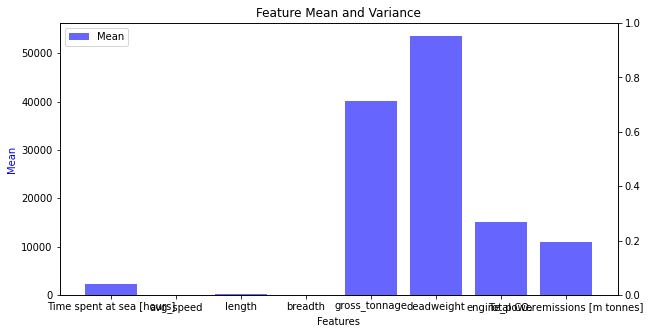

In [3]:
import matplotlib.pyplot as plt
# 选取指定的特征
features = df[['Time spent at sea [hours]',
               'avg_speed',
               'length',
               'breadth',
               'gross_tonnage',
               'deadweight',
               'engine_power',
              'Total CO₂ emissions [m tonnes]']]

# 计算均值和方差
feature_means = features.mean()
feature_vars = features.var()

# 打印均值和方差
print("Feature Means:\n", feature_means)
print("\nFeature Variances:\n", feature_vars)

# 绘制均值和方差的柱状图
fig, ax1 = plt.subplots(figsize=(10, 5))

# 坐标轴
ax2 = ax1.twinx()

# 画均值
ax1.bar(feature_means.index, feature_means.values, color='b', alpha=0.6, label='Mean')

# 画方差
# ax2.plot(feature_vars.index, feature_vars.values, color='r', marker='o', linestyle='-', label='Variance')

# 设置标签和标题
ax1.set_xlabel("Features")
ax1.set_ylabel("Mean", color='b')
# ax2.set_ylabel("Variance", color='r')
plt.xticks(rotation=45)
plt.title("Feature Mean and Variance")

# 显示图例
ax1.legend(loc='upper left')
# ax2.legend(loc='upper right')

plt.show()

# model 1

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.utils.data
import torch.optim as optim
import torch.nn as nn
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


df = pd.read_csv('./Updated Data/co2.csv')
df= pd.read_csv('./Updated Data/co2_0122.csv')
# print(df)
features = df[['Time spent at sea [hours]',
#                'max_speed',
               'avg_speed',
               'length',
               'breadth',
               'engine_power',
              'gross_tonnage',
              'deadweight',
               'type no'
              ]]
target = df['Total CO₂ emissions [m tonnes]']

# 设置超参数
input_size = features.shape[1]
hidden_size_1 = 64
hidden_size_2 = 32
output_size = 1
batch_size = 32

scaler = StandardScaler()
feature_data = scaler.fit_transform(features)

train_X = torch.tensor(feature_data, dtype=torch.float32)
train_Y = torch.tensor(target.values, dtype=torch.float32).view(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(train_X, train_Y, test_size=0.2, random_state=42)

train_data = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_data= torch.utils.data.TensorDataset(X_test,y_test)
test_loader = torch.utils.data.DataLoader(test_data,batch_size=batch_size)

      Unnamed: 0.1  Unnamed: 0  length  breadth  gross_tonnage  deadweight  \
0                0           0   123.0     19.0         9149.0      1968.0   
1                1           1   124.0     19.0         7171.0      2838.0   
2                2           2   108.0     20.0         6040.0      2566.0   
3                3           3   128.0     19.0        10154.0      1132.0   
4                4           4   125.0     18.0         9183.0      2254.0   
...            ...         ...     ...      ...            ...         ...   
7913          7913        8751   182.0     31.0        24332.0     39269.0   
7914          7914        8801   182.0     31.0        24332.0     39172.0   
7915          7915        8802   182.0     31.0        24350.0     39278.0   
7916          7916        8811   199.0     32.0        34000.0     60000.0   
7917          7917        8888   140.0     16.0         6305.0      8095.0   

      avg_speed  Time spent at sea [hours]  Total CO₂ emissions

In [5]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size, dropout_rate=0.3):
        super(ImprovedMLP, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Linear(input_size, hidden_size_1),
            nn.BatchNorm1d(hidden_size_1),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate)
        )
        
        self.layer2 = nn.Sequential(
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.BatchNorm1d(hidden_size_2),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate)
        )
        
        self.layer3 = nn.Linear(hidden_size_2, output_size)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, a=0.1)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x

model = ImprovedMLP(
    input_size=input_size,
    hidden_size_1=hidden_size_1,
    hidden_size_2=hidden_size_2,
    output_size=output_size
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=50, 
    verbose=True
)

D:\Anaconda3\envs\ai\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [6]:
import numpy as np
from sklearn.metrics import r2_score
import copy

best_r2 = float('-inf')
best_model = None
num_epochs=1500

for epoch in range(num_epochs):
    model.train()
    for i, (inputs, labels) in enumerate(train_loader):
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        # 保存预测值和真实值
        train_outputs = []
        train_labels = []
        test_outputs =[]
        test_labels= []
        
        # 在训练集上计算R2
        for inputs, labels in train_loader:
            outputs = model(inputs)
            train_outputs.extend(outputs.numpy())
            train_labels.extend(labels.numpy())
        train_r2 = r2_score(train_labels, train_outputs)
        
        # 在测试集上计算R2
        for inputs, labels in test_loader:
            outputs = model(inputs)
            test_outputs.extend(outputs.numpy())
            test_labels.extend(labels.numpy())
        test_r2 = r2_score(test_labels, test_outputs)
        
        # 保存表现较好的模型
        if test_r2 > best_r2:
            best_r2 = test_r2
            best_model = copy.deepcopy(model)
            torch.save(best_model.state_dict(), 'better_mlp.pth')

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()},train_R2:{train_r2:.6f}, test_R2:{test_r2:.6f}')
#         l1_regularization = torch.tensor(0.)
#         l2_regularization = torch.tensor(0.)
#         for param in model.parameters():
#             l1_regularization += torch.norm(param, 1)
#             l2_regularization += torch.norm(param, 2)
#         print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}, R2: {train_r2:.4f}, L1: {l1_regularization}, L2: {l2_regularization}')

print(f'Best R2 Score: {best_r2:.4f}')

Epoch [50/1500], Loss: 177166336.0,train_R2:-0.063488, test_R2:-0.054802
Epoch [100/1500], Loss: 94118168.0,train_R2:0.694281, test_R2:0.678666
Epoch [150/1500], Loss: 30863258.0,train_R2:0.895164, test_R2:0.872282
Epoch [200/1500], Loss: 62521164.0,train_R2:0.900966, test_R2:0.877683
Epoch [250/1500], Loss: 54025524.0,train_R2:0.890551, test_R2:0.868100
Epoch [300/1500], Loss: 35558144.0,train_R2:0.905362, test_R2:0.883063
Epoch [350/1500], Loss: 33250702.0,train_R2:0.894005, test_R2:0.871099
Epoch [400/1500], Loss: 86747576.0,train_R2:0.900451, test_R2:0.877537
Epoch [450/1500], Loss: 54350508.0,train_R2:0.909979, test_R2:0.886998
Epoch [500/1500], Loss: 15315249.0,train_R2:0.915316, test_R2:0.891834
Epoch [550/1500], Loss: 17400618.0,train_R2:0.913796, test_R2:0.891044
Epoch [600/1500], Loss: 46624244.0,train_R2:0.910882, test_R2:0.888734
Epoch [650/1500], Loss: 11059639.0,train_R2:0.916119, test_R2:0.891598
Epoch [700/1500], Loss: 30273250.0,train_R2:0.907250, test_R2:0.884701
Epoc

In [ ]:
# better_mlp.pth


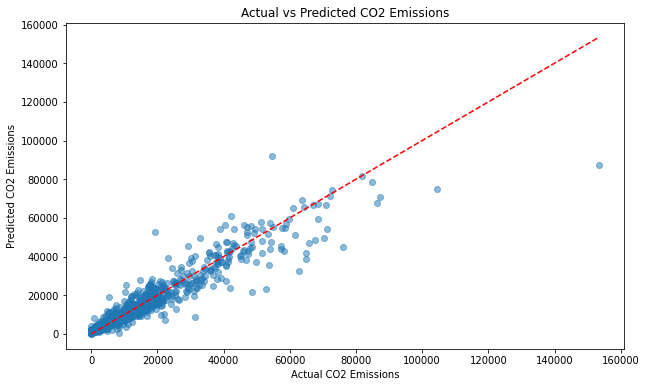

In [7]:
# 实际值与MLP模型预测值的对比
model.load_state_dict(torch.load('better_mlp.pth'))

import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    test_predictions = []
    test_actuals = []
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        test_predictions.extend(outputs.numpy())
        test_actuals.extend(batch_y.numpy())

    test_predictions = np.array(test_predictions)
    test_actuals =np.array(test_actuals)

plt.figure(figsize=(10, 6))
plt.scatter(test_actuals, test_predictions, alpha=0.5)
plt.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], 'r--')
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Actual vs Predicted CO2 Emissions')
plt.show()

In [68]:
# 训练模型
for epoch in range(num_epochs):
    for i, (inputs, labels) in enumerate(train_loader):
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 打印训练信息和计算正则化项
    if (epoch+1) % 50 == 0:
        l1_regularization = torch.tensor(0.)
        l2_regularization = torch.tensor(0.)
        for param in model.parameters():
            l1_regularization += torch.norm(param, 1)
            l2_regularization += torch.norm(param, 2)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}, L1: {l1_regularization}, L2: {l2_regularization}')



Epoch [50/1500], Loss: 67214624.0, L1: 2535.335205078125, L2: 312.4927978515625
Epoch [100/1500], Loss: 12227266.0, L1: 2944.1162109375, L2: 364.02972412109375
Epoch [150/1500], Loss: 19038780.0, L1: 3147.9619140625, L2: 389.6878662109375
Epoch [200/1500], Loss: 67485152.0, L1: 3290.50927734375, L2: 406.7293395996094
Epoch [250/1500], Loss: 50218008.0, L1: 3396.937255859375, L2: 419.61090087890625
Epoch [300/1500], Loss: 16245156.0, L1: 3484.108642578125, L2: 430.0811767578125
Epoch [350/1500], Loss: 11884951.0, L1: 3555.0517578125, L2: 438.55987548828125
Epoch [400/1500], Loss: 94586680.0, L1: 3617.4306640625, L2: 446.0340576171875
Epoch [450/1500], Loss: 39605444.0, L1: 3672.11474609375, L2: 452.46673583984375
Epoch [500/1500], Loss: 33590412.0, L1: 3719.4404296875, L2: 458.164306640625
Epoch [550/1500], Loss: 136354544.0, L1: 3764.425048828125, L2: 463.55145263671875
Epoch [600/1500], Loss: 4659933.0, L1: 3808.619873046875, L2: 468.9869689941406
Epoch [650/1500], Loss: 28276578.0, L

In [65]:
# 测试模型
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    mse_scores = []
    mae_scores = []
    r2_scores = []
    for inputs, targets in train_loader:
        outputs = model(inputs)
        outputs = outputs.detach().numpy()
        targets = targets.numpy()
        #计算均方误差和平均绝对误差
        mse = mean_squared_error(targets, outputs)
        mae = mean_absolute_error(targets, outputs)
        r2 = r2_score(targets, outputs)
        mse_scores.append(mse)
        mae_scores.append(mae)
        r2_scores.append(r2)
#         total += targets.size(0)
        correct += (mse - mae)
    avg_mse = np.mean(mse_scores)
    avg_mae = np.mean(mae_scores)
    avg_r2 = np.mean(r2_scores)
    print('Average MSE: {:.4f}, Average MAE: {:.4f}, Average R2: {:.4f}'.format(avg_mse, avg_mae, avg_r2))

Average MSE: 17904888.0000, Average MAE: 2293.2046, Average R2: 0.8966


In [ ]:
torch.save(model.state_dict(), '/mnt/mlp_model.pt')

In [ ]:
#model 2

In [4]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('./Updated Data/co2.csv')
df = pd.read_csv('./Updated Data/co2_0121.csv')
df = pd.read_csv('./Updated Data/co2_0122.csv')
df.info()

features = df[['Time spent at sea [hours]',
               'avg_speed',
#                'max_speed',
               'length',
               'breadth',
               'gross_tonnage',
               'deadweight',
              'engine_power',
              'type no']]
#               ]]
target = df['Total CO₂ emissions [m tonnes]']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

class CO2Dataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = CO2Dataset(X_train, y_train)
test_dataset = CO2Dataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7918 entries, 0 to 7917
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0.1                    7918 non-null   int64  
 1   Unnamed: 0                      7918 non-null   int64  
 2   length                          7918 non-null   float64
 3   breadth                         7918 non-null   float64
 4   gross_tonnage                   7918 non-null   float64
 5   deadweight                      7918 non-null   float64
 6   avg_speed                       7918 non-null   float64
 7   Time spent at sea [hours]       7918 non-null   float64
 8   Total CO₂ emissions [m tonnes]  7918 non-null   float64
 9   type no                         7918 non-null   float64
 10  engine_power                    7918 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 680.6 KB


In [5]:
# Transformer 模型
class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_heads, dropout=0.1):
        super(TransformerModel, self).__init__()
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim*4,
            dropout=dropout,
            batch_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # Add sequence dimension
        x = x.unsqueeze(1)  
        
        x = self.embedding(x)
        
        # Transformer layers
        x = self.transformer_encoder(x)
        x = x.squeeze(1)
        x = self.fc(x)
        return x


# 初始化模型、损失函数和优化器
input_dim = X_train.shape[1]
hidden_dim = 64
num_layers = 2
num_heads = 4

model = TransformerModel(input_dim, hidden_dim, num_layers, num_heads)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def evaluate_model(model, data_loader, scaler_y):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            outputs = model(batch_X)
            predictions.extend(outputs.numpy())
            actuals.extend(batch_y.numpy())
    
    # Convert back to original scale
    predictions = scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1))
    actuals = scaler_y.inverse_transform(np.array(actuals).reshape(-1, 1))
    
    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    
    return mse, r2



In [16]:
# Training loop
num_epochs = 200
best_r2 = float('-inf')  # 初始化为负无穷
best_epoch = 0

print("Training started...")
print("Epoch | Train Loss | Train R2 | Test R2")
print("--------------------------------------------" )

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    # Training phase
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Calculate metrics for both train and test sets
    train_mse, train_r2 = evaluate_model(model, train_loader, scaler_y)
    test_mse, test_r2 = evaluate_model(model, test_loader, scaler_y)
    
    # Print metrics every 10 epochs
    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1:5d} | {total_loss/len(train_loader):.4f} | {train_r2:.4f} | {test_r2:.4f}")
    
    # Save best model
    if test_r2 > best_r2:
        best_r2 = test_r2
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth')
        import joblib

        # 保存标准化器
        joblib.dump(scaler_X, 'best_scaler_X.pkl')
        joblib.dump(scaler_y, 'best_scaler_y.pkl')

print("\nTraining completed!")
print(f"Best model saved at epoch {best_epoch} with R2 score: {best_r2:.4f}")

# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
final_train_mse, final_train_r2 = evaluate_model(model, train_loader, scaler_y)
final_test_mse, final_test_r2 = evaluate_model(model, test_loader, scaler_y)

print("\nFinal Results:")
print(f"Train MSE: {final_train_mse:.2f}")
print(f"Train R2 Score: {final_train_r2:.4f}")
print(f"Test MSE: {final_test_mse:.2f}")
print(f"Test R2 Score: {final_test_r2:.4f}")

Training started...
Epoch | Train Loss | Train R2 | Test R2
--------------------------------------------
    5 | 0.1073 | 0.9037 | 0.8753
   10 | 0.1056 | 0.9112 | 0.8840
   15 | 0.0866 | 0.9133 | 0.8804
   20 | 0.0856 | 0.9221 | 0.8987
   25 | 0.0820 | 0.9133 | 0.8857
   30 | 0.0784 | 0.9333 | 0.9070
   35 | 0.0861 | 0.9221 | 0.8960
   40 | 0.0729 | 0.9378 | 0.9143
   45 | 0.0798 | 0.9318 | 0.9058
   50 | 0.0677 | 0.9430 | 0.9147
   55 | 0.0679 | 0.9321 | 0.9049
   60 | 0.0642 | 0.9448 | 0.9174
   65 | 0.0665 | 0.9403 | 0.9139
   70 | 0.0623 | 0.9454 | 0.9193
   75 | 0.0614 | 0.9450 | 0.9165
   80 | 0.0583 | 0.9466 | 0.9199
   85 | 0.0618 | 0.9456 | 0.9144
   90 | 0.0649 | 0.9410 | 0.9083
   95 | 0.0578 | 0.9404 | 0.9070
  100 | 0.0531 | 0.9499 | 0.9149
  105 | 0.0573 | 0.9482 | 0.9234
  110 | 0.0612 | 0.9506 | 0.9159
  115 | 0.0557 | 0.9524 | 0.9227
  120 | 0.0527 | 0.9564 | 0.9234
  125 | 0.0582 | 0.9532 | 0.9227
  130 | 0.0522 | 0.9588 | 0.9245
  135 | 0.0478 | 0.9596 | 0.9251
  14

In [6]:
# Training loop
######################4.7
num_epochs = 200
best_r2 = float('-inf')  # 初始化为负无穷
best_epoch = 0

print("Training started...")
print("Epoch | Train Loss | Train R2 | Test R2")
print("--------------------------------------------" )

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    # Training phase
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Calculate metrics for both train and test sets
    train_mse, train_r2 = evaluate_model(model, train_loader, scaler_y)
    test_mse, test_r2 = evaluate_model(model, test_loader, scaler_y)
    
    # Print metrics every 10 epochs
    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1:5d} | {total_loss/len(train_loader):.4f} | {train_r2:.4f} | {test_r2:.4f}")
    
    # Save best model
    if test_r2 > best_r2:
        best_r2 = test_r2
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth')
        import joblib

        # 保存标准化器
        joblib.dump(scaler_X, 'best_scaler_X.pkl')
        joblib.dump(scaler_y, 'best_scaler_y.pkl')

print("\nTraining completed!")
print(f"Best model saved at epoch {best_epoch} with R2 score: {best_r2:.4f}")

# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
final_train_mse, final_train_r2 = evaluate_model(model, train_loader, scaler_y)
final_test_mse, final_test_r2 = evaluate_model(model, test_loader, scaler_y)

print("\nFinal Results:")
print(f"Train MSE: {final_train_mse:.2f}")
print(f"Train R2 Score: {final_train_r2:.4f}")
print(f"Test MSE: {final_test_mse:.2f}")
print(f"Test R2 Score: {final_test_r2:.4f}")

Training started...
Epoch | Train Loss | Train R2 | Test R2
--------------------------------------------
    5 | 0.1056 | 0.9064 | 0.8762
   10 | 0.0965 | 0.9103 | 0.8826
   15 | 0.0914 | 0.9325 | 0.8973
   20 | 0.0862 | 0.9106 | 0.8747
   25 | 0.0852 | 0.9374 | 0.9023
   30 | 0.0872 | 0.9327 | 0.8966
   35 | 0.0784 | 0.9305 | 0.8963
   40 | 0.0727 | 0.9398 | 0.9009
   45 | 0.0647 | 0.9362 | 0.9008
   50 | 0.0665 | 0.9425 | 0.9053
   55 | 0.0669 | 0.9401 | 0.9035
   60 | 0.0644 | 0.9440 | 0.9053
   65 | 0.0655 | 0.9352 | 0.8969
   70 | 0.0607 | 0.9502 | 0.9146
   75 | 0.0577 | 0.9459 | 0.9101
   80 | 0.0597 | 0.9387 | 0.8950
   85 | 0.0594 | 0.9467 | 0.9098
   90 | 0.0667 | 0.9426 | 0.8996
   95 | 0.0601 | 0.9268 | 0.8830
  100 | 0.0534 | 0.9512 | 0.9135
  105 | 0.0538 | 0.9546 | 0.9086
  110 | 0.0508 | 0.9482 | 0.9049
  115 | 0.0538 | 0.9569 | 0.9067
  120 | 0.0511 | 0.9542 | 0.9058
  125 | 0.0510 | 0.9497 | 0.9127
  130 | 0.0540 | 0.9590 | 0.9122
  135 | 0.0479 | 0.9598 | 0.9175
  14

In [13]:
torch.save(model.state_dict(), './TransformerModel_co21.pth')

import joblib

# 保存标准化器
# joblib.dump(scaler_X, 'scaler_X.pkl')
# joblib.dump(scaler_y, 'scaler_y.pkl')
joblib.dump(scaler_X, 'scaler_X1.pkl')
joblib.dump(scaler_y, 'scaler_y1.pkl')

['scaler_y1.pkl']

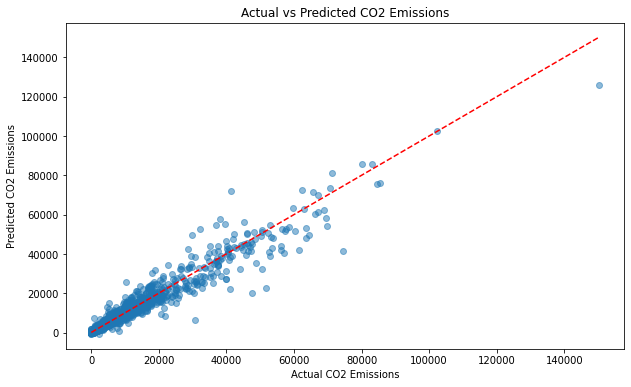

In [16]:
# 实际值与transformer模型预测值的对比
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    test_predictions = []
    test_actuals = []
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        test_predictions.extend(outputs.numpy())
        test_actuals.extend(batch_y.numpy())

    test_predictions = scaler_y.inverse_transform(np.array(test_predictions))
    test_actuals = scaler_y.inverse_transform(np.array(test_actuals))

plt.figure(figsize=(10, 6))
plt.scatter(test_actuals, test_predictions, alpha=0.5)
plt.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], 'r--')
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Actual vs Predicted CO2 Emissions')
plt.show()

# for i in range(100):
#     print(f'{test_actuals[i]}vs{test_predictions[i]}')

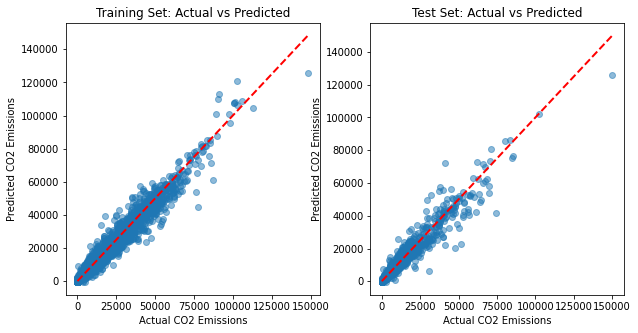

In [19]:
# 实际值与transformer模型预测值的对比
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    test_predictions = []
    test_actuals = []
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        test_predictions.extend(outputs.numpy())
        test_actuals.extend(batch_y.numpy())

    test_predictions = scaler_y.inverse_transform(np.array(test_predictions))
    test_actuals = scaler_y.inverse_transform(np.array(test_actuals))
    
with torch.no_grad():
    train_predictions = []
    train_actuals = []
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        train_predictions.extend(outputs.numpy())
        train_actuals.extend(batch_y.numpy())

    train_predictions = scaler_y.inverse_transform(np.array(train_predictions))
    train_actuals = scaler_y.inverse_transform(np.array(train_actuals))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(train_actuals, train_predictions, alpha=0.5)
plt.plot([min(train_actuals), max(train_actuals)], [min(train_actuals), max(train_actuals)], 'r--',lw=2)
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Training Set: Actual vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(test_actuals, test_predictions, alpha=0.5)
plt.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], 'r--',lw=2)
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Test Set: Actual vs Predicted')
plt.show()



# plt.show()
# # 5. Visualize predictions vs actual values
# plt.figure(figsize=(10, 5))

# # Training data
# plt.subplot(1, 2, 1)
# plt.scatter(y_train, y_pred_train, alpha=0.5)
# plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--', lw=2)
# plt.xlabel('Actual CO2 Emissions')
# plt.ylabel('Predicted CO2 Emissions')
# plt.title('Training Set: Actual vs Predicted')


# y_test=all_actuals
# y_pred_test=all_predictions
# # Test data
# plt.subplot(1, 2, 2)
# plt.scatter(y_test, y_pred_test, alpha=0.5)
# plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
# plt.xlabel('Actual CO2 Emissions')
# plt.ylabel('Predicted CO2 Emissions')
# plt.title('Test Set: Actual vs Predicted')

# plt.tight_layout()
# plt.show()

In [14]:
import torch
import pandas as pd
import joblib
import numpy as np
from sklearn.inspection import permutation_importance

# 读取数据
df = pd.read_csv('./Updated Data/co2.csv')
df = pd.read_csv('./Updated Data/co2_0122.csv')

# 选择特征和目标变量
features = df[['Time spent at sea [hours]',
               'avg_speed',
               'length',
               'breadth',
               'gross_tonnage',
               'deadweight',
               'engine_power',
              'type no']]
target = df['Total CO₂ emissions [m tonnes]']

# 加载标准化器
# scaler_X = joblib.load('scaler_X.pkl')
# scaler_y = joblib.load('scaler_y.pkl')
scaler_X = joblib.load('scaler_X1.pkl')
scaler_y = joblib.load('scaler_y1.pkl')
# 标准化输入特征
X_scaled = scaler_X.transform(features)
y_scaled = scaler_y.transform(target.values.reshape(-1, 1))

# 转换为 PyTorch 张量
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# 加载 Transformer 模型
# from TransformerModel import TransformerModel  # 确保你有 TransformerModel 类

model = TransformerModel(input_dim=7, hidden_dim=64, num_layers=2, num_heads=4)  # 创建模型实例
model.load_state_dict(torch.load('./best_model.pth'))  # 加载权重
model.eval()  # 设为评估模式


D:\Anaconda3\envs\ai\lib\site-packages\sklearn\base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- type no

  warnings.warn(message, FutureWarning)


ValueError: X has 8 features, but StandardScaler is expecting 7 features as input.

In [7]:
from sklearn.metrics import mean_squared_error

# 计算基准 MSE
with torch.no_grad():
    y_pred = model(X_tensor).numpy()
baseline_mse = mean_squared_error(y_scaled, y_pred)

# 计算特征重要性
feature_importance = []
for i in range(X_scaled.shape[1]):
    X_permuted = X_scaled.copy()
    np.random.shuffle(X_permuted[:, i])  # 打乱第 i 个特征
    
    with torch.no_grad():
        y_permuted_pred = model(torch.tensor(X_permuted, dtype=torch.float32)).numpy()
    
    permuted_mse = mean_squared_error(y_scaled, y_permuted_pred)
    importance = permuted_mse - baseline_mse
    feature_importance.append(importance)

# 归一化重要性
feature_importance = np.array(feature_importance)
feature_importance /= feature_importance.sum()

# 打印特征重要性
importance_df = pd.DataFrame({'Feature': features.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


NameError: name 'X_tensor' is not defined

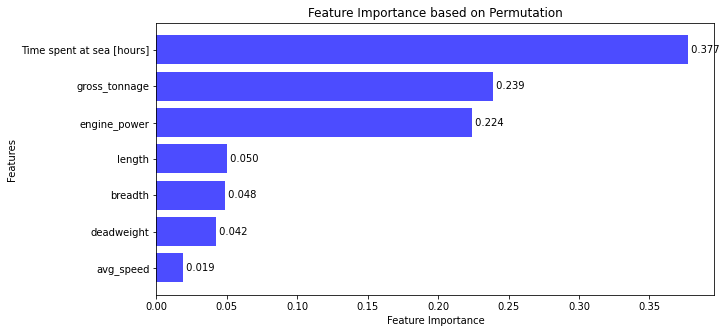

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='b', alpha=0.7)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance based on Permutation')
plt.gca().invert_yaxis()  

for index, value in enumerate(importance_df['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center')
    
plt.show()


In [18]:
import shap

explainer = shap.Explainer(model, X_tensor)
shap_values = explainer(X_tensor)

# 绘制 SHAP Summary Plot
shap.summary_plot(shap_values, X_scaled, feature_names=features.columns)


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


TypeError: 'Tensor' object is not callable

In [10]:
# import torch
# import torch.nn as nn
# import pandas as pd
# import numpy as np

# class TransformerModel(nn.Module):
#     def __init__(self, input_dim, hidden_dim, num_layers, num_heads, dropout=0.1):
#         super(TransformerModel, self).__init__()
        
#         self.embedding = nn.Linear(input_dim, hidden_dim)
        
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=hidden_dim,
#             nhead=num_heads,
#             dim_feedforward=hidden_dim*4,
#             dropout=dropout,
#             batch_first=True
#         )
        
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.fc = nn.Linear(hidden_dim, 1)
        
#     def forward(self, x):
#         x = x.unsqueeze(1)  
#         x = self.embedding(x)
#         x = self.transformer_encoder(x)
#         x = x.squeeze(1)
#         x = self.fc(x)
#         return x

# # 创建预测函数
# def predict_co2(input_data, model, scaler_X, scaler_y):

#     model.eval()
    
#     # 转换输入数据格式
#     if isinstance(input_data, pd.DataFrame):
#         input_data = input_data.values
    
#     input_scaled = scaler_X.transform(input_data)
#     input_tensor = torch.FloatTensor(input_scaled)
    
#     # 预测
#     with torch.no_grad():
#         predictions = model(input_tensor)
        
#     # 转换回原始尺度
#     predictions = scaler_y.inverse_transform(predictions.numpy().reshape(-1, 1))
    
#     return predictions


# if __name__ == "__main__":
#     # 
#     input_dim = 7  # 特征数量
#     input_dim=X_train.shape[1]
#     model = TransformerModel(
#         input_dim=input_dim,
#         hidden_dim=64,
#         num_layers=2,
#         num_heads=4
#     )
    
#     model.load_state_dict(torch.load('./TransformerModel_co2.pth'))
    
#     # 示例数据
# #     features = df[['Time spent at sea [hours]',
# #                'avg_speed',
# #                'max_speed',
# #                'length',
# #                'breadth',
# #                'gross_tonnage',
# #                'deadweight',
# #               'engine_power']]
#     test_data = pd.DataFrame({
#         'Time spent at sea [hours]': [2229.75],
#         'avg_speed': [13.9],
#         'max_speed':[16.0]
#         'length': [128.0],
#         'breadth': [19.0],
#         'gross_tonnage': [10154.0],
#         'deadweight': [2566.0],
#         'engine_power': [12358.92],
#     })
    
#     # 加载标准化器（需要保存）
#     import joblib
#     scaler_X = joblib.load('scaler_X.pkl')
#     scaler_y = joblib.load('scaler_y.pkl')
    
#     # 预测
#     predictions = predict_co2(test_data, model, scaler_X, scaler_y)
#     print(f"预测的CO2排放量: {predictions[0][0]:.2f} 吨")

SyntaxError: invalid syntax (1132644252.py, line 79)

In [18]:
import pandas as pd
df = pd.read_csv('./Updated Data/co2_0122.csv')
df=df.drop(columns=['Unnamed: 0.1','Unnamed: 0'])
df.head(20)

,length,breadth,gross_tonnage,deadweight,avg_speed,Time spent at sea [hours],Total CO₂ emissions [m tonnes],type no,engine_power
0,123.0,19.0,9149.0,1968.0,10.9,1771.00,6097.81,11.0,12051.960000
1,124.0,19.0,7171.0,2838.0,13.9,2992.36,6674.22,12.0,6153.600000
2,108.0,20.0,6040.0,2566.0,13.9,2494.00,5355.81,12.0,6210.340000
3,128.0,19.0,10154.0,1132.0,13.0,2229.75,10163.69,11.0,14186.980000
4,125.0,18.0,9183.0,2254.0,11.0,1272.25,5866.95,11.0,12395.600000
5,121.0,19.0,4986.0,1029.0,18.9,3090.30,20072.86,11.0,9805.376000
6,120.0,21.0,12035.0,2151.0,11.8,2288.92,10986.29,11.0,10021.890000
7,118.0,20.0,9182.0,1185.0,15.2,1582.27,8019.53,11.0,11387.620000
8,117.0,20.0,11907.0,1560.0,12.7,1495.20,7610.02,11.0,10894.620000
9,120.0,21.0,12187.0,2541.0,14.2,1096.67,6378.12,11.0,7723.582000


In [ ]:
# 模型3

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('./Updated Data/co2.csv')
# 提取特征和目标变量
data = df[['Time spent at sea [hours]',
#                'max_speed',
               'avg_speed',
               'length',
               'breadth',
               'engine_power',
              'gross_tonnage',
              'deadweight'
              ]]

# 提取特征和目标变量
x = data.values
y = df['Total CO₂ emissions [m tonnes]']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=4)

# 初始化随机森林回归模型并设置参数
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 训练模型
rf_model.fit(x_train, y_train)

# 预测，并将 get_numpy 数组转换为 numpy 数组
y_pred = rf_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE:{mse:.6f}, R2:{r2:.6f}')

MSE:21471000.203521, R2:0.888295
